# MLP Training — Telco Churn
Treinamento da rede neural MLP com PyTorch, comparação com baselines e análise de custo FP vs FN.

In [13]:
import logging
import random
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '..')
from src.preprocessing import _normalize_columns

import mlflow
import mlflow.pytorch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, average_precision_score, f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s — %(message)s')
logger = logging.getLogger(__name__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_PATH = '../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'
TARGET = 'Churn Value'
NUMERIC_FEATURES = ['Tenure Months', 'Monthly Charges', 'Total Charges']
CATEGORICAL_FEATURES = [
    'Gender', 'Senior Citizen', 'Partner', 'Dependents',
    'Phone Service', 'Multiple Lines', 'Internet Service',
    'Online Security', 'Online Backup', 'Device Protection',
    'Tech Support', 'Streaming TV', 'Streaming Movies',
    'Contract', 'Paperless Billing', 'Payment Method',
]

## 1. Carregar e pré-processar dados

In [14]:
df = _normalize_columns(pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'))
df['Total Charges']   = pd.to_numeric(df['Total Charges'],   errors='coerce')
df['Monthly Charges'] = pd.to_numeric(df['Monthly Charges'], errors='coerce')

X = df[CATEGORICAL_FEATURES + NUMERIC_FEATURES]
y = df[TARGET].values

# stratify=y mantém a proporção de churn (~26%) em treino e teste
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler()),
    ]), NUMERIC_FEATURES),
    ('cat', Pipeline([
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), CATEGORICAL_FEATURES),
])

# fit apenas no treino — evita data leakage
X_train = preprocessor.fit_transform(X_train_raw)
X_test  = preprocessor.transform(X_test_raw)

print(f'Train: {X_train.shape} | Test: {X_test.shape} | Churn rate: {y_train.mean():.2%}')

Train: (5634, 46) | Test: (1409, 46) | Churn rate: 26.54%


## 2. Definição do modelo MLP

In [15]:
class ChurnMLP(nn.Module):
    """MLP para classificação binária de churn.

    Arquitetura: Linear → BatchNorm → ReLU → Dropout (repetido por camada oculta)
    Saída: probabilidade de churn em [0, 1] via Sigmoid.
    """
    def __init__(self, input_dim, hidden_dims, dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for dim in hidden_dims:
            layers += [
                nn.Linear(prev, dim),
                nn.BatchNorm1d(dim),  # estabiliza o treino normalizando as ativações por batch
                nn.ReLU(),            # não-linearidade — permite aprender padrões além de fronteiras lineares
                nn.Dropout(dropout),  # desativa neurônios aleatoriamente para reduzir overfitting
            ]
            prev = dim
        layers += [nn.Linear(prev, 1), nn.Sigmoid()]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## 3. Loop de treino com early stopping

In [16]:
def train_model(model, X_tr, y_tr, X_val, y_val, config):
    """Treina o modelo com early stopping e loga métricas por epoch no MLflow."""
    epochs     = config.get('epochs', 100)
    batch_size = config.get('batch_size', 64)
    lr         = config.get('lr', 1e-3)
    patience   = config.get('patience', 10)

    X_t = torch.tensor(X_tr,  dtype=torch.float32)
    y_t = torch.tensor(y_tr,  dtype=torch.float32).unsqueeze(1)
    X_v = torch.tensor(X_val, dtype=torch.float32)
    y_v = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True)

    # pos_weight penaliza mais os erros na classe minoritária (churn)
    pos_weight = torch.tensor([(y_tr == 0).sum() / (y_tr == 1).sum()], dtype=torch.float32)
    # BCEWithLogitsLoss é numericamente mais estável que BCELoss + Sigmoid separados
    # ATENÇÃO: como usamos BCEWithLogitsLoss, o modelo NÃO deve ter Sigmoid na saída durante o treino
    # — aqui a Sigmoid está no forward() apenas para inferência; no treino ela é substituída internamente
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {'train': [], 'val': []}
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(X_batch)
        train_loss /= len(X_t)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_v), y_v).item()

        history['train'].append(train_loss)
        history['val'].append(val_loss)
        mlflow.log_metrics({'train_loss': train_loss, 'val_loss': val_loss}, step=epoch)

        # early stopping: interrompe se val_loss não melhorar por `patience` epochs consecutivas
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                logger.info('Early stopping na epoch %d', epoch)
                break

    model.load_state_dict(best_state)  # restaura o melhor estado, não o último
    return model, history

## 4. Treinar MLP com MLflow tracking

In [17]:
CONFIG = {'epochs': 100, 'batch_size': 64, 'lr': 1e-3, 'patience': 10}
HIDDEN_DIMS = [64, 32]
DROPOUT = 0.3
INPUT_DIM = X_train.shape[1]

mlflow.set_tracking_uri('../mlruns')
mlflow.set_experiment('churn-mlp')

with mlflow.start_run(run_name='mlp-baseline') as run:
    mlflow.log_params({**CONFIG, 'hidden_dims': str(HIDDEN_DIMS), 'dropout': DROPOUT})

    model = ChurnMLP(INPUT_DIM, HIDDEN_DIMS, DROPOUT)
    model, history = train_model(model, X_train, y_train, X_test, y_test, CONFIG)

    # Avaliação final
    model.eval()
    with torch.no_grad():
        probs = model(torch.tensor(X_test, dtype=torch.float32)).squeeze().numpy()
    preds = (probs >= 0.5).astype(int)

    metrics = {
        'f1':        f1_score(y_test, preds),
        'roc_auc':   roc_auc_score(y_test, probs),
        'pr_auc':    average_precision_score(y_test, probs),
        'precision': precision_score(y_test, preds),
        'recall':    recall_score(y_test, preds),
    }
    mlflow.log_metrics(metrics)
    mlflow.pytorch.log_model(model, 'model')
    print('Métricas MLP:', {k: round(v, 4) for k, v in metrics.items()})

2026/05/02 16:28:40 INFO mlflow.tracking.fluent: Experiment with name 'churn-mlp' does not exist. Creating a new experiment.
2026/05/02 16:28:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/02 16:28:45 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/02 16:28:51 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Métricas MLP: {'f1': 0.6233, 'roc_auc': 0.8357, 'pr_auc': 0.6263, 'precision': 0.576, 'recall': 0.6791}


## 5. Curva de loss (treino vs validação)

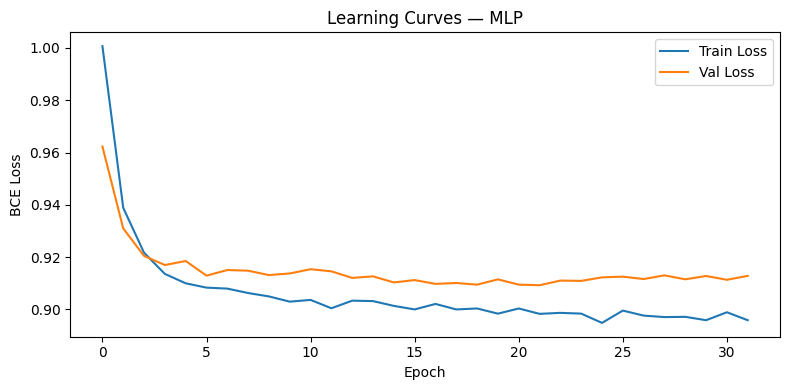

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history['train'], label='Train Loss')
ax.plot(history['val'],   label='Val Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('Learning Curves — MLP')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/loss_curve.png', dpi=100)
plt.show()

## 6. Comparação com baselines

In [19]:
from sklearn.metrics import average_precision_score  # adicione junto aos outros imports

def eval_sklearn(clf, X_tr, y_tr, X_te, y_te, run_name):
    clf.fit(X_tr, y_tr)
    preds_  = clf.predict(X_te)
    probs_  = clf.predict_proba(X_te)[:, 1] if hasattr(clf, 'predict_proba') else preds_.astype(float)
    m = {
        'f1':        f1_score(y_te, preds_),
        'roc_auc':   roc_auc_score(y_te, probs_),
        'pr_auc':    average_precision_score(y_te, probs_),  # <-- adicionado
        'precision': precision_score(y_te, preds_),
        'recall':    recall_score(y_te, preds_),
    }
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({'model': run_name})
        mlflow.log_metrics(m)
    return m

results = {
    'Dummy':              eval_sklearn(DummyClassifier(strategy='most_frequent', random_state=SEED),
                                       X_train, y_train, X_test, y_test, 'dummy'),
    'LogisticRegression': eval_sklearn(LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
                                       X_train, y_train, X_test, y_test, 'logistic-regression'),
    'MLP (PyTorch)':      metrics,
}

pd.DataFrame(results).T.round(4)

,f1,roc_auc,pr_auc,precision,recall
Dummy,0.0000,0.5000,0.2654,0.0000,0.0000
LogisticRegression,0.6130,0.8414,0.6324,0.5034,0.7834
MLP (PyTorch),0.6233,0.8357,0.6263,0.5760,0.6791


## 7. Matriz de confusão — MLP

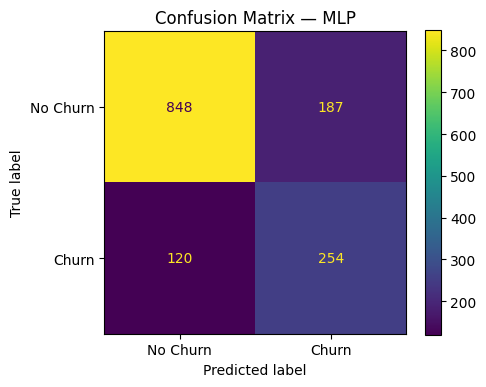

In [20]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, preds, display_labels=['No Churn', 'Churn'], ax=ax)
ax.set_title('Confusion Matrix — MLP')
plt.tight_layout()
plt.savefig('../docs/confusion_matrix.png', dpi=100)
plt.show()

## 8. Análise de custo FP vs FN

In [21]:
# FP = campanha de retenção desnecessária (R$50)
# FN = cliente perdido sem intervenção (R$500)
COST_FP, COST_FN = 50.0, 500.0

def business_cost(y_true, y_pred):
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    return {'fp': fp, 'fn': fn, 'total_cost': fp * COST_FP + fn * COST_FN}

dummy_clf = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy_clf.fit(X_train, y_train)

lr_clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
lr_clf.fit(X_train, y_train)

cost_df = pd.DataFrame({
    'Dummy':              business_cost(y_test, dummy_clf.predict(X_test)),
    'LogisticRegression': business_cost(y_test, lr_clf.predict(X_test)),
    'MLP':                business_cost(y_test, preds),
}).T
cost_df['total_cost'] = cost_df['total_cost'].map('R$ {:,.0f}'.format)
cost_df

,fp,fn,total_cost
Dummy,0.0,374.0,"R$ 187,000"
LogisticRegression,289.0,81.0,"R$ 54,950"
MLP,187.0,120.0,"R$ 69,350"


## 9. Threshold ótimo por custo mínimo

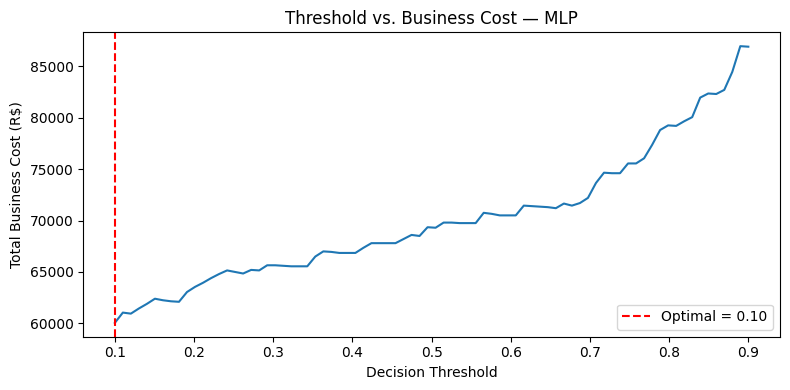

Threshold ótimo: 0.10 — Custo mínimo: R$ 60,050


In [22]:
thresholds = np.linspace(0.1, 0.9, 80)
costs = [business_cost(y_test, (probs >= t).astype(int))['total_cost'] for t in thresholds]

best_t = thresholds[np.argmin(costs)]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, costs)
ax.axvline(best_t, color='red', linestyle='--', label=f'Optimal = {best_t:.2f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Total Business Cost (R$)')
ax.set_title('Threshold vs. Business Cost — MLP')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/threshold_cost.png', dpi=100)
plt.show()
print(f'Threshold ótimo: {best_t:.2f} — Custo mínimo: R$ {min(costs):,.0f}')

## 10. Performance por Subgrupo (threshold de produção = 0.10)


=== Contract ===


,n,churn_real,f1,roc_auc,pr_auc,precision,recall
Contract,,,,,,,
Month-to-month,773,42.6%,0.661,0.742,0.660,0.551,0.827
One year,300,12.0%,0.204,0.698,0.232,0.385,0.139
Two year,336,2.7%,0.000,0.758,0.065,0.000,0.000



=== Senior Citizen ===


,n,churn_real,f1,roc_auc,pr_auc,precision,recall
Senior Citizen,,,,,,,
No,1187,23.3%,0.592,0.834,0.602,0.521,0.685
Yes,222,44.1%,0.724,0.780,0.690,0.607,0.898



=== Internet Service ===


,n,churn_real,f1,roc_auc,pr_auc,precision,recall
Internet Service,,,,,,,
DSL,484,20.0%,0.539,0.818,0.543,0.484,0.608
Fiber optic,613,41.1%,0.683,0.773,0.678,0.565,0.865
No,312,8.0%,0.000,0.874,0.327,0.000,0.000


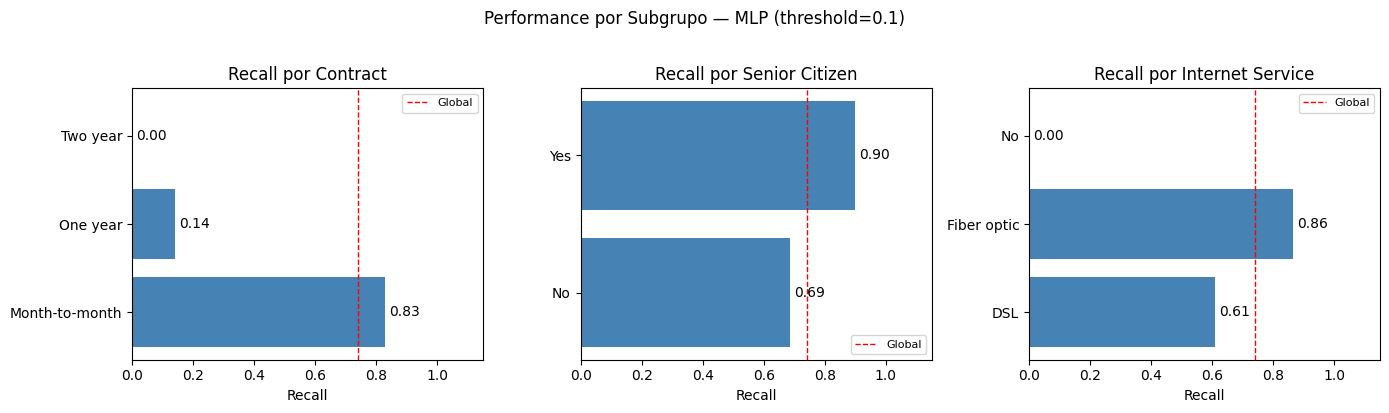

Salvo em docs/subgroup_performance.png


In [23]:
PROD_THRESHOLD = 0.10
preds_prod = (probs >= PROD_THRESHOLD).astype(int)

test_eval = X_test_raw.reset_index(drop=True).copy()
test_eval['y_true'] = y_test
test_eval['y_pred'] = preds_prod
test_eval['y_prob'] = probs

SUBGROUPS = ['Contract', 'Senior Citizen', 'Internet Service']

def subgroup_metrics(df, feature):
    rows = []
    for value in sorted(df[feature].unique()):
        mask = df[feature] == value
        y_t  = df.loc[mask, 'y_true']
        y_p  = df.loc[mask, 'y_pred']
        y_pr = df.loc[mask, 'y_prob']
        churn_rate = y_t.mean()
        has_both_classes = len(y_t.unique()) == 2
        rows.append({
            feature:      value,
            'n':          int(mask.sum()),
            'churn_real': f'{churn_rate:.1%}',
            'f1':         round(f1_score(y_t, y_p, zero_division=0), 3),
            'roc_auc':    round(roc_auc_score(y_t, y_pr), 3) if has_both_classes else float('nan'),
            'pr_auc':     round(average_precision_score(y_t, y_pr), 3) if has_both_classes else float('nan'),
            'precision':  round(precision_score(y_t, y_p, zero_division=0), 3),
            'recall':     round(recall_score(y_t, y_p, zero_division=0), 3),
        })
    return pd.DataFrame(rows).set_index(feature)

for feat in SUBGROUPS:
    print()
    print(f'=== {feat} ===')
    display(subgroup_metrics(test_eval, feat))

fig, axes = plt.subplots(1, len(SUBGROUPS), figsize=(14, 4))
for ax, feat in zip(axes, SUBGROUPS):
    df_sg = subgroup_metrics(test_eval, feat).reset_index()
    bars = ax.barh(df_sg[feat].astype(str), df_sg['recall'], color='steelblue')
    ax.bar_label(bars, fmt='%.2f', padding=3)
    ax.set_xlim(0, 1.15)
    ax.set_xlabel('Recall')
    ax.set_title(f'Recall por {feat}')
    ax.axvline(recall_score(test_eval['y_true'], test_eval['y_pred'], zero_division=0),
               color='red', linestyle='--', linewidth=1, label='Global')
    ax.legend(fontsize=8)

plt.suptitle(f'Performance por Subgrupo — MLP (threshold={PROD_THRESHOLD})', y=1.02)
plt.tight_layout()
plt.savefig('../docs/subgroup_performance.png', dpi=100, bbox_inches='tight')
plt.show()
print('Salvo em docs/subgroup_performance.png')